## 3.4. Metrics and scoring: quantifying the quality of predictions


### 3.4.1. Choose score function?
- Which scoring function should I use?
- Which scoring function is a good one for my task?

It is useful to distinguish two steps:
- Predicting
- Decision making

**Predicting**: Usually, the response variable is a random variable, in the sense that there is no deterministic function of the features. $Y=g(X)$ , we usually choose a stat. property as the result. Such as mean,median,quantile 

It is best used for both: 
- as loss function for model training 
- as metric/score in model evaluation and model comparison.

**Decision Making**:The result is a single outcome,There are many scoring functions which measure different aspects of such a decision, most of them are covered with or derived from the `metrics.confusion_matrix`.

|functional         | scoring or loss function                          |  response `y`       |   prediction|
|-------------------|---------------------------------------------------|---------------------|-------------|
|**Classification**||||
|mode               | zero-one loss        |multi-class           |``predict``, categorical|
**Regression**
|mean                |mean_squared_error|  all reals             |``predict``, all reals|
|median              |mean_absolute_error |         all reals      |       ``predict``, all reals|
|quantile           |pinball_loss     |           all reals         |    ``predict``, all reals|

1. $R^2$ gives the same ranking as squared error.


### 3.4.2. Scoring API overview
There are 3 different APIs for evaluating the quality of a model’s predictions:  
1. Estimator score method: Estimators(model) have a score method providing a default evaluation criterion.
- classifiers ：  accuracy 
- regressors：$R^2$
2. Scoring parameter: Model-evaluation tools that use cross-validation (such as model_selection.GridSearchCV..) rely on an internal scoring strategy.`scoring` param.  
3. Metric functions: The sklearn.metrics module implements functions assessing prediction error for specific purposes.

### 3.4.4. classification metrics
- `sklearn.metrics`


#### 3.4.4.15 Receiver operating characteristic (ROC)
ROC: 接受者操作特征
- ROC曲线用于评估二分类模型。
- 横轴: 假阳率 (FPR)。
- 纵轴：真阳率 (TPR)。 
- 理想点：位于左上角，FPR为0，TPR为1。 表示曲线下面积 ？
- 陡峭度：曲线越陡峭，模型越好。表示最大化TPR同时最小化FPR。
- AUC值：曲线下面积 (Area Under Curve)，范围0到1。综合分数，
- 灵敏度：TPR = TP / (TP + FN)
- 阈值隐藏在点上，左下到右上，阈值从高到低变化。

In [11]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y = np.array([0, 0, 1, 1]) # 
scores = np.array([0.1, 0.4, 0.35, 0.8])
# roc曲线点
fpr, tpr, thresholds = roc_curve(y, scores, pos_label=1) # pos_label为阳性标签
print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)


FPR: [0.  0.  0.5 0.5 1. ]
TPR: [0.  0.5 0.5 1.  1. ]
Thresholds: [ inf 0.8  0.4  0.35 0.1 ]


结果解释：
- 阈值为0.8时，表示有0.8及以上概率分为阳性。此时FPR=0.0，TPR=0.5。抓到了一半的阳性，且没有误报。
- 阈值为0.4时，表示有0.4及以上概率分为阳性。此时FPR=0.5，TPR=1.0。抓到了所有阳性，但误报了一半的阴性。

AUC: 0.75


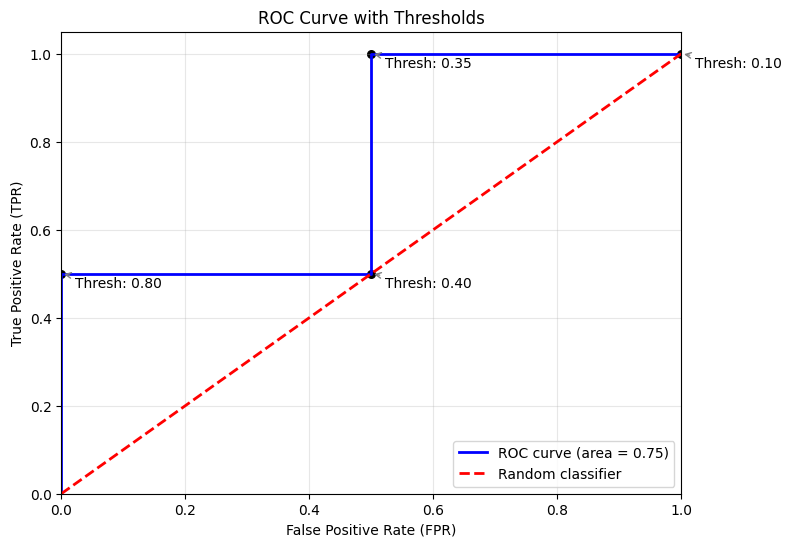

In [ ]:
# 计算AUC值
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# 绘制随机分类器对角线
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random classifier')

# --- 新增：循环标注阈值 ---
for i, thresh in enumerate(thresholds):
    # 跳过第一个起始阈值（通常是 max(score)+1），避免标注重叠
    if i == 0: continue 
    # 标出点
    plt.scatter(fpr[i], tpr[i], color='black', s=30) 
    # 在点旁边标注具体的阈值数值
    plt.annotate(f'Thresh: {thresh:.2f}', 
                 xy=(fpr[i], tpr[i]), 
                 xytext=(10, -10), # 文字偏移量
                 textcoords='offset points', 
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve with Thresholds')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


**思想：滑动阈值**
- 分类模型输出样本属于某一类别的概率。比如放贷模型，输出某人违约的概率是0.7。
- 但是实际决策可以进行人为调整，可以设定一个阈值，即允许最大的违约概率。
  - 比如阈值设为0.6，则概率大于0.6的样本被判为违约，概率小于0.6的样本被判为不违约。
  - 这表示对模型风险的容忍度。阈值为0.1表示非常保守，尽量遵守模型建议；阈值为0.9表示非常激进，愿意承担较大风险。
- ROC曲线记录下不同阈值下的FPR和TPR，从而评估模型在不同风险容忍度下的表现。
- 

### 3.4.6. Regression metrics

The sklearn.metrics module implements several loss, score, and utility functions to **measure regression performance**. Some of those have been enhanced to handle the **multioutput** case (): mean_squared_error, mean_absolute_error, r2_score...

These functions have a multioutput keyword argument:


#### 3.4.6.1. R² score, the coefficient of determination
The r2_score function computes the coefficient of determination through the **proportion** of explained **variance**.
$$R² = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$


$(-\inf, 1]$
- R^2 = 1 ：perfect
-  R^2 = 0 ：imperfect, ability as the mean predict (all $\hat{y}_i = \bar{y}$)
-  R^2 < 0 ：terrible

$denominator=0$:
- NaN -> 1.0
- -inf -> 0.0


In [3]:
from sklearn.metrics import r2_score
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]
r2_score(y_true, y_pred)


0.9486081370449679

In [4]:
y_true = [[0.5, 1], [-1, 1], [7, -6]]
y_pred = [[0, 2], [-1, 2], [8, -5]]
r2_score(y_true, y_pred, multioutput='variance_weighted')
r2_score(y_true, y_pred, multioutput='uniform_average')
r2_score(y_true, y_pred, multioutput='raw_values')
r2_score(y_true, y_pred, multioutput=[0.3, 0.7])

0.9253456221198156

#### 3.4.6.2 others
- Mean Absolute Error (MAE)
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

- Mean Squared Error (MSE)
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Median Absolute Error (MedAE)
$$
MedAE = \text{median} \left( \left| y_i - \hat{y}_i \right| \right)
$$
    - MedAE : outliers不敏感


- Max Error
$$
Max Error = \max \left( \left| y_i - \hat{y}_i \right| \right)



#### 3.4.6.12. Visual evaluation of regression models
PredictionErrorDisplay class allows to visually inspect the prediction errors of a model in two different manners.